# 01 — Exploratory Data Analysis
**BSAN 6200 Assignment 3 | Student A | Disneyland Reviews**

Groups: California · Paris · Hong Kong

## 1. Install packages
Run this cell once if any package is missing in your environment.

In [1]:
# Run once if needed
!pip install -q kagglehub gensim wordcloud nltk scikit-learn pandas matplotlib pyLDAvis

## 2. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import re
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud

import kagglehub
import nltk
import pyLDAvis

# pyLDAvis sklearn integration — handle version differences gracefully
try:
    from pyLDAvis import sklearn as pyldavis_sklearn
except Exception:
    try:
        import pyLDAvis.sklearn as pyldavis_sklearn
    except Exception:
        pyldavis_sklearn = None

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

from IPython.display import display

In [3]:
# Download required NLTK resources
for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

## 3. Download and load the Disneyland dataset

In [4]:
KAGGLE_DATASET = "arushchillar/disneyland-reviews"
dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)

print("Dataset folder:", dataset_path)
print("Files:", os.listdir(dataset_path))

Dataset folder: /Users/sadafsarbazi/.cache/kagglehub/datasets/arushchillar/disneyland-reviews/versions/1
Files: ['DisneylandReviews.csv']


In [5]:
# Locate the CSV and load it with encoding fallback
csv_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the Kaggle dataset folder.")
csv_file_name = csv_files[0]
if len(csv_files) > 1:
    print("Multiple CSV files found:", csv_files, "— using first.")

csv_path = os.path.join(dataset_path, csv_file_name)
print("Using CSV file:", csv_path)

# The Disneyland Reviews dataset is often latin1-encoded
encodings_to_try = ["utf-8", "latin1", "ISO-8859-1", "cp1252"]
df = None
for enc in encodings_to_try:
    try:
        df = pd.read_csv(csv_path, encoding=enc)
        print(f"Loaded successfully with encoding: {enc}")
        break
    except UnicodeDecodeError:
        print(f"Failed with encoding: {enc}")

if df is None:
    raise ValueError("Could not read the CSV with any of the tested encodings.")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Using CSV file: /Users/sadafsarbazi/.cache/kagglehub/datasets/arushchillar/disneyland-reviews/versions/1/DisneylandReviews.csv
Failed with encoding: utf-8
Loaded successfully with encoding: latin1
Shape: (42656, 6)
Columns: ['Review_ID', 'Rating', 'Year_Month', 'Reviewer_Location', 'Review_Text', 'Branch']


,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong


## 4. Select required columns and define the three location groups

In [6]:
location_col = "Branch"
text_col     = "Review_Text"
rating_col   = "Rating"

df = df[[location_col, text_col, rating_col]].copy()
df.rename(columns={
    location_col: "location",
    text_col:     "review_text",
    rating_col:   "rating"
}, inplace=True)

# Normalise dtypes
df["location"]    = df["location"].astype(str).str.strip()
df["review_text"] = df["review_text"].astype(str).fillna("").str.strip()
df["rating"]      = pd.to_numeric(df["rating"], errors="coerce")

# Map raw branch names to clean group labels
def normalize_location(x):
    x = str(x).strip().lower()
    if "california" in x:
        return "California"
    elif "paris" in x:
        return "Paris"
    elif "hong" in x:
        return "Hong Kong"
    else:
        return "Other"

df["location_clean"] = df["location"].apply(normalize_location)
target_groups = ["California", "Paris", "Hong Kong"]
df = df[df["location_clean"].isin(target_groups)].copy()

print("Review counts per location:")
print(df["location_clean"].value_counts())
df.head()

Review counts per location:
location_clean
California    19406
Paris         13630
Hong Kong      9620
Name: count, dtype: int64


,location,review_text,rating,location_clean
0,Disneyland_HongKong,If you've ever been to Disneyland anywhere you...,4,Hong Kong
1,Disneyland_HongKong,Its been a while since d last time we visit HK...,4,Hong Kong
2,Disneyland_HongKong,Thanks God it wasn t too hot or too humid wh...,4,Hong Kong
3,Disneyland_HongKong,HK Disneyland is a great compact park. Unfortu...,4,Hong Kong
4,Disneyland_HongKong,"the location is not in the city, took around 1...",4,Hong Kong


## 5. Exploratory Data Analysis

The assignment requires EDA across all three groups covering:
- Document count
- Average and median review length
- Average rating
- Review length distributions
- Vocabulary size (raw)
- Vocabulary overlap across groups
- Initial word clouds

In [7]:
# Summary statistics per group
df["review_length_words"] = df["review_text"].apply(lambda x: len(str(x).split()))

eda_summary = (
    df.groupby("location_clean")
      .agg(
          n_reviews          = ("review_text",          "count"),
          avg_review_length  = ("review_length_words",  "mean"),
          median_review_length=("review_length_words",  "median"),
          avg_rating         = ("rating",               "mean")
      )
      .round(2)
      .reset_index()
)
print("EDA Summary:")
display(eda_summary)

EDA Summary:


,location_clean,n_reviews,avg_review_length,median_review_length,avg_rating
0,California,19406,115.45,71.0,4.41
1,Hong Kong,9620,102.26,70.0,4.20
2,Paris,13630,169.37,112.0,3.96


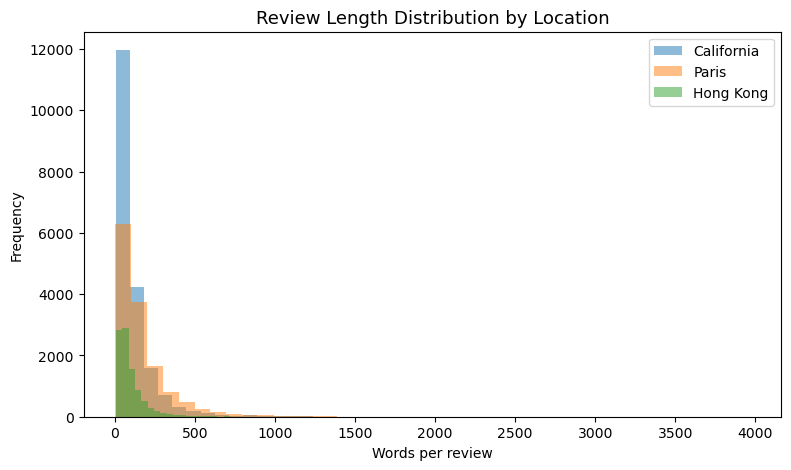

In [8]:
# Review length distribution by location
import os
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(9, 5))
for group in target_groups:
    subset = df[df["location_clean"] == group]["review_length_words"]
    plt.hist(subset, bins=40, alpha=0.5, label=group)

plt.title("Review Length Distribution by Location", fontsize=13)
plt.xlabel("Words per review")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("figures/eda_review_length_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


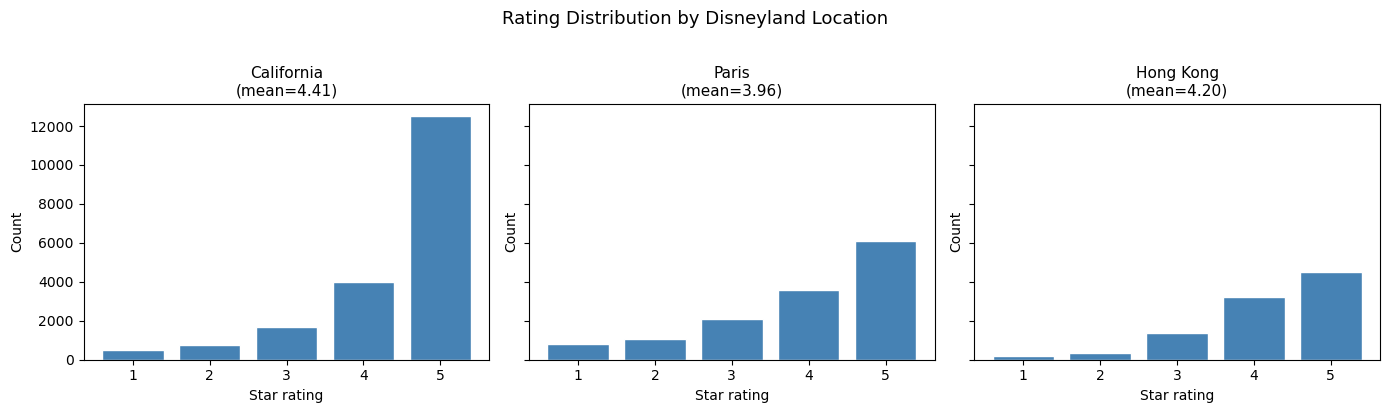

In [9]:
# Rating distribution by location
# Required EDA element: shows how sentiment differs across parks
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, group in zip(axes, target_groups):
    subset = df[df["location_clean"] == group]["rating"].dropna()
    counts = subset.value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
    ax.set_title(group, fontsize=12)
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Count")
    mean_r = subset.mean()
    ax.axhline(0, color="none")  # spacer
    ax.set_title(f"{group}\n(mean={mean_r:.2f})", fontsize=11)

plt.suptitle("Rating Distribution by Disneyland Location", fontsize=13, y=1.02)
plt.tight_layout()
import os; os.makedirs("figures", exist_ok=True)
plt.savefig("figures/eda_rating_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


In [10]:
# Raw vocabulary size per group
def raw_vocab_size(texts):
    joined = " ".join(texts.astype(str)).lower()
    words  = re.findall(r"\b[a-z']+\b", joined)
    return len(set(words))

raw_vocab_rows = []
for group in target_groups:
    subset = df.loc[df["location_clean"] == group, "review_text"]
    raw_vocab_rows.append({
        "location_clean":    group,
        "raw_vocabulary_size": raw_vocab_size(subset)
    })

raw_vocab_df = pd.DataFrame(raw_vocab_rows)
print("Raw vocabulary size per group:")
display(raw_vocab_df)

Raw vocabulary size per group:


,location_clean,raw_vocabulary_size
0,California,23956
1,Paris,26902
2,Hong Kong,16369


In [11]:
# Vocabulary overlap across locations (Jaccard similarity)
# High overlap means locations share common language; low overlap = location-specific themes
def get_raw_vocab(texts):
    joined = " ".join(texts.astype(str)).lower()
    return set(re.findall(r"\b[a-z']+\b", joined))

raw_vocab_sets = {
    group: get_raw_vocab(df.loc[df["location_clean"] == group, "review_text"])
    for group in target_groups
}

vocab_overlap_rows = []
for i, group_a in enumerate(target_groups):
    for group_b in target_groups[i + 1:]:
        overlap = raw_vocab_sets[group_a].intersection(raw_vocab_sets[group_b])
        union   = raw_vocab_sets[group_a].union(raw_vocab_sets[group_b])
        jaccard = len(overlap) / len(union) if len(union) > 0 else 0
        vocab_overlap_rows.append({
            "group_1":            group_a,
            "group_2":            group_b,
            "shared_unique_words": len(overlap),
            "jaccard_similarity":  round(jaccard, 4)
        })

vocab_overlap_df = pd.DataFrame(vocab_overlap_rows)
print("Vocabulary overlap between groups:")
display(vocab_overlap_df)

Vocabulary overlap between groups:


,group_1,group_2,shared_unique_words,jaccard_similarity
0,California,Paris,14284,0.3906
1,California,Hong Kong,11124,0.3809
2,Paris,Hong Kong,11279,0.3526


In [12]:
# Top 20 raw words per group (before any cleaning)
def get_top_raw_words(text_series, top_n=20):
    joined = " ".join(text_series.astype(str)).lower()
    words  = re.findall(r"\b[a-z']+\b", joined)
    return Counter(words).most_common(top_n)

for group in target_groups:
    print(f"\nTop raw words for {group}:")
    print(get_top_raw_words(df.loc[df["location_clean"] == group, "review_text"]))


Top raw words for California:
[('the', 122994), ('and', 72039), ('to', 68965), ('a', 52065), ('we', 38035), ('of', 36015), ('it', 31468), ('in', 31189), ('i', 30044), ('for', 29853), ('was', 29682), ('is', 27449), ('you', 26831), ('park', 18784), ('that', 18206), ('on', 17396), ('at', 17244), ('disneyland', 17008), ('but', 16528), ('were', 15967)]

Top raw words for Paris:
[('the', 132719), ('and', 74487), ('to', 66879), ('a', 53899), ('of', 39472), ('we', 37994), ('in', 35971), ('for', 33673), ('was', 33461), ('it', 29880), ('is', 27676), ('you', 27611), ('i', 25157), ('were', 19364), ('but', 19165), ('park', 18823), ('at', 18377), ('on', 17358), ('as', 17234), ('are', 16469)]

Top raw words for Hong Kong:
[('the', 58237), ('and', 30770), ('to', 28579), ('a', 22171), ('is', 15024), ('of', 14709), ('in', 14436), ('was', 13893), ('we', 13733), ('for', 13511), ('it', 13398), ('you', 11164), ('i', 10997), ('disneyland', 8017), ('but', 7998), ('are', 7627), ('park', 7620), ('with', 7392),

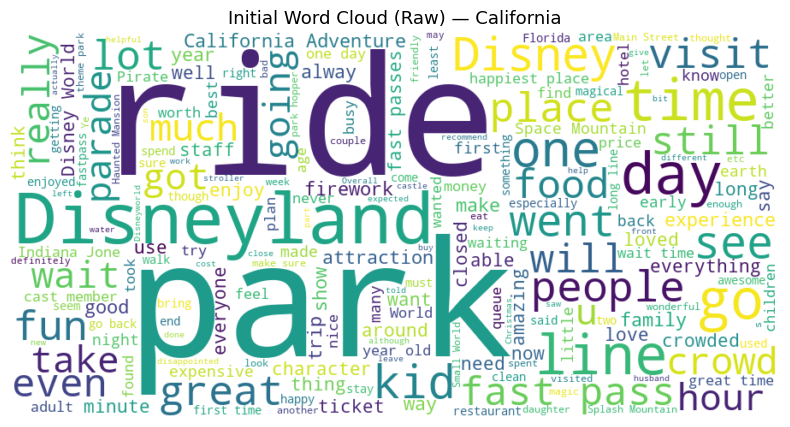

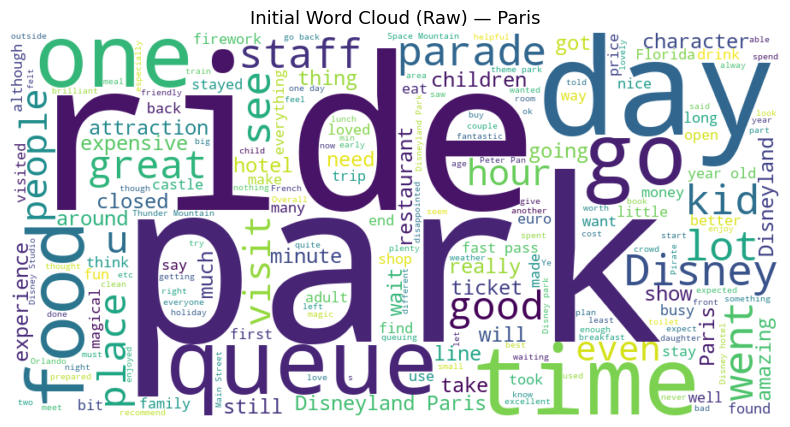

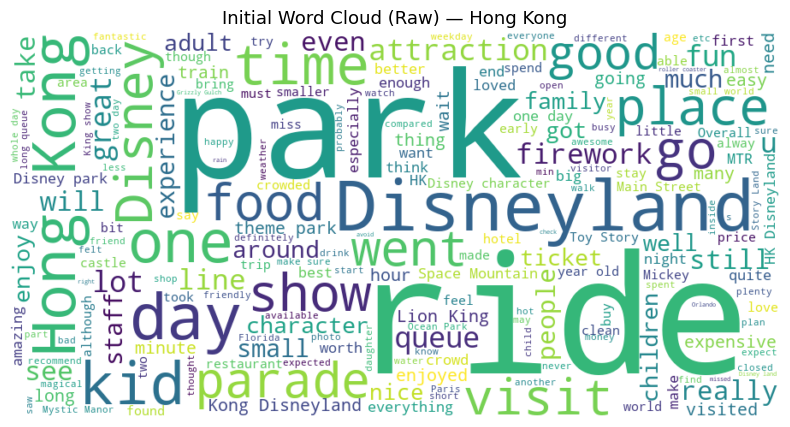

In [13]:
# Initial word clouds (raw text)
import os
os.makedirs("figures", exist_ok=True)

def plot_wordcloud(texts, title, save_path=None):
    joined = " ".join(texts.astype(str))
    wc = WordCloud(width=900, height=450, background_color="white").generate(joined)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=13)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()

for group in target_groups:
    subset    = df.loc[df["location_clean"] == group, "review_text"]
    safe_name = group.lower().replace(" ", "_")
    plot_wordcloud(
        subset,
        f"Initial Word Cloud (Raw) — {group}",
        save_path=f"figures/wordcloud_raw_{safe_name}.png"
    )


### EDA Interpretation

The three Disneyland locations differ meaningfully in review count, review length, vocabulary size, and rating patterns:

- **California** has the most reviews (19,406) and a moderate average length (115 words), suggesting a large, engaged English-speaking visitor base writing focused feedback.
- **Paris** has the longest reviews by far (avg 169 words, median 112) — nearly 50% longer than California and Hong Kong. This likely reflects European visitors writing more detailed narrative accounts, and may include multilingual visitors who write more expansively in English.
- **Hong Kong** has the fewest reviews (9,620) and the shortest average length (102 words), which may reflect a different reviewer demographic or a more concise feedback culture.

**Ratings:** California has the highest average rating (4.41), followed by Hong Kong (4.20), and Paris the lowest (3.96). This gap is meaningful — Paris reviews are not only longer but also less satisfied on average, suggesting more negative experiences that visitors feel compelled to describe in detail.

**Vocabulary overlap:** Jaccard similarity scores are **low-to-moderate** across all three pairs (CA–Paris: 0.39, CA–HK: 0.38, Paris–HK: 0.35). Despite sharing the Disney brand, each park has substantial location-specific vocabulary — roughly 60% of each park's vocabulary is unique to that location. This strongly motivates fitting **separate topic models per group** rather than pooling reviews: a pooled model would suppress the location-specific themes that are most analytically interesting.
